# ML from DFT data

In [1]:
import pickle
import os
import glob
import numpy as np
import pdb
import pandas as pd
from importlib.machinery import SourceFileLoader
import re
import sys
from tqdm.notebook import tqdm_notebook
from seaborn import heatmap
import seaborn as sns
from BopFoxFeaturizer.HelperFunctions import get_useful_features
from BopFoxFeaturizer.HelperFunctions import cleanfeaturenames
from BopFoxFeaturizer.HelperFunctions import histoff_realfeatures
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('legend',fontsize=24)
plt.rc('axes',labelsize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)
from BopFoxFeaturizer.FeatureConcatenate import stackdata
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from BopFoxFeaturizer.Featurizer import Featurizer
from BopFoxFeaturizer import HelperFunctions as HF
#stackdata = SourceFileLoader('stackdata','BopFoxFeaturizer/FeatureConcatenate.py').load_module().stackdata
# Original DFT Data
%run SourceDevelopementVersion.py
# which loads Featu
import glob

# Parameters 

In [2]:
CASE = 'INITIAL'  #, 'INITIAL', RELAXED
MODEL = 'ORTHOGONALOS' #, 'ORTHOGONAL', 'CANONICAL','ORTOGONALOS'
CUT_OFF = 'TABLECUTOFF' # 'TABLECUTOFF', 'HISTCUTOFF'
E_MODE ='WUBIND'
C_RITERION = 'test_score'  # test_score, train_score, err
SEARCH_MODE = 'score_only' #score_only, index_too
TARGET = 'EF'
MOMENTS = 15

# Helpeer Functions 

In [3]:
from Tools import CaseNamer, Plotting

In [4]:
FileNames = CaseNamer(
    CASE, MODEL,
    CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE, TARGET=TARGET
)

# Load Features

## Load briefsummary and its features

In [5]:
BS = StructSummaryParser().BriefSummary
Features = Featurizer(BS)

## Load the BOP for the selected case

In [6]:
BOPCOEF_FILE = f'CNAveragedCRCOW_{CASE}_NSC_{MODEL}_{CUT_OFF}_{E_MODE}_{MOMENTS}.pkl'
BopfoxFeatures = pd.read_pickle(BOPCOEF_FILE)
#BopfoxFeatures.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
#BopfoxFeatures.drop(columns=['NSC_U_bind'], inplace=True)

In [7]:
BopfoxFeatures

,all_NSC_U_bind_0,all_NSC_U_bond_atom_0,all_NSC_U_bond_atom_list_0,CN12_a_NSC_U_bond_atom_list_0,CN12_b_NSC_U_bond_atom_list_0,CN12_c_NSC_U_bond_atom_list_0,CN13_a_NSC_U_bond_atom_list_0,CN14_a_NSC_U_bond_atom_list_0,CN14_b_NSC_U_bond_atom_list_0,CN15_a_NSC_U_bond_atom_list_0,...,all_NSC_Binf_0,CN12_a_NSC_Binf_0,CN12_b_NSC_Binf_0,CN12_c_NSC_Binf_0,CN13_a_NSC_Binf_0,CN14_a_NSC_Binf_0,CN14_b_NSC_Binf_0,CN15_a_NSC_Binf_0,CN16_a_NSC_Binf_0,CN16_b_NSC_Binf_0
Co_pv10W_sv14.C36-ABBAB.FM,-294.347975,-335.840358,-27.763904,-17.035042,-19.588367,-71.958212,0.0,0.000000,0.0,0.0,...,5.830383,5.926394,5.748687,5.961436,0.0,0.00000,0.0,0.0,5.711266,5.779452
Co_pv10W_sv14.C36-ABBAB.NM,-294.347975,-335.840358,-27.763904,-17.035042,-19.588367,-71.958212,0.0,0.000000,0.0,0.0,...,5.830383,5.926394,5.748687,5.961436,0.0,0.00000,0.0,0.0,5.711266,5.779452
Co_pv10W_sv14.C36-ABBBA.FM,-294.347975,-335.840358,-27.763904,-17.035042,-19.588367,-71.958212,0.0,0.000000,0.0,0.0,...,5.830383,5.926394,5.748687,5.961436,0.0,0.00000,0.0,0.0,5.711266,5.779452
Co_pv10W_sv14.C36-ABBBA.NM,-294.347975,-335.840358,-27.763904,-17.035042,-19.588367,-71.958212,0.0,0.000000,0.0,0.0,...,5.830383,5.926394,5.748687,5.961436,0.0,0.00000,0.0,0.0,5.711266,5.779452
Co_pv10W_sv14.C36-BABAB.FM,-294.347975,-335.840358,-27.763904,-17.035042,-19.588367,-71.958212,0.0,0.000000,0.0,0.0,...,5.830383,5.926394,5.748687,5.961436,0.0,0.00000,0.0,0.0,5.711266,5.779452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W_sv1.bcc.FM,-21.021407,-21.021407,-21.021407,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,6.222663,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000
W_sv2.hcp.FM,-40.187813,-40.187813,-30.140859,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,5.187294,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000
W_sv4.fcc-cubic.FM,-81.028519,-81.028519,-35.449977,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,5.763108,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000
W_sv53.R.NM,-1077.572644,-1078.835373,-40.344047,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,5.435779,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000


## clean features: reduntandly convert all features to float and mean across sites

In [8]:
BopfoxFeatures.dropna(how='any',inplace=True)
Mag = Features.MagFeature[BopfoxFeatures.index]
BopfoxFeatures['MagConfig'] = Mag

In [9]:
BOP = BopfoxFeatures

## define the column names by type of feature

In [10]:
allcolumns = BOP.columns

In [11]:
columns_Mag =BOP.columns[BOP.columns.str.contains('MagConfig')]
columns_U =BOP.columns[BOP.columns.str.contains('U_bind')]
columns_bn = BOP.columns[BOP.columns.str.contains('bn')]
columns_sigma =BOP.columns[BOP.columns.str.contains('SIGMA')] 
columns_moments = BOP.columns[BOP.columns.str.contains('moment')]
columns_an = BOP.columns[BOP.columns.str.contains('an')]

In [12]:
feature_titles = pd.Series(
    HF.cleanfeaturenames([ s.replace('NSC_','').replace('MagConfig_0','MagConfig').replace('bind_0','bind') for s in allcolumns ]), index=allcolumns
)

In [13]:
repeated = BOP.columns[BOP.columns.str.contains('all_NSC_U_bond_atom_list')]

In [14]:
real_feature = HF.get_useful_features(BOP, allcolumns)

In [15]:
len(real_feature)

491

In [16]:
def colsgroup(kind):
    return [ f for f in real_feature if kind in f] 

In [17]:
useful = {f: colsgroup(f) for f in ['an','bn','moment','SIGMA', 'U_bind','MagConfig']}

# Targets

$ \Delta E_F  = \dfrac{1}{N_{atoms}} \left( E_{Total} - \sum _{i} N_i E_i \right) $

In [18]:
groundstates=Features.get_ground_states_energies()
BS['EF'] = Features.get_formation_energy(ground_states_dic=groundstates)
BS = BS.dropna()
DATA = BOP.copy()
DATA[['B0','V0','EF','E0']]=BS[['B0','V0','EF','E0']]

## Distribution of targets

### $E_{F}$

In [19]:
Out_In_First = DATA[~((DATA['EF']>-1) & (DATA['EF']<2))]

In [20]:
DATA = DATA[(DATA['EF'] > -1) & (DATA['EF']< 2)]

### $E_0$

In [21]:
DATA = DATA[(DATA['E0']>-100) & (DATA['E0']<10)]

In [22]:
DATA.shape

(1684, 657)

## B0

In [23]:
DATA = DATA[(DATA['B0'])>0 & (DATA['B0']<500)]

## V0

In [24]:
DATA = DATA[DATA['V0']<50]

In [25]:
DATA.shape

(1681, 657)

## Drop Nans !

In [26]:
DATA.dropna(how='any', axis=0,inplace=True)

In [27]:
DATA.shape

(1681, 657)

# Classification and weighting

Text(0, 0.5, '')

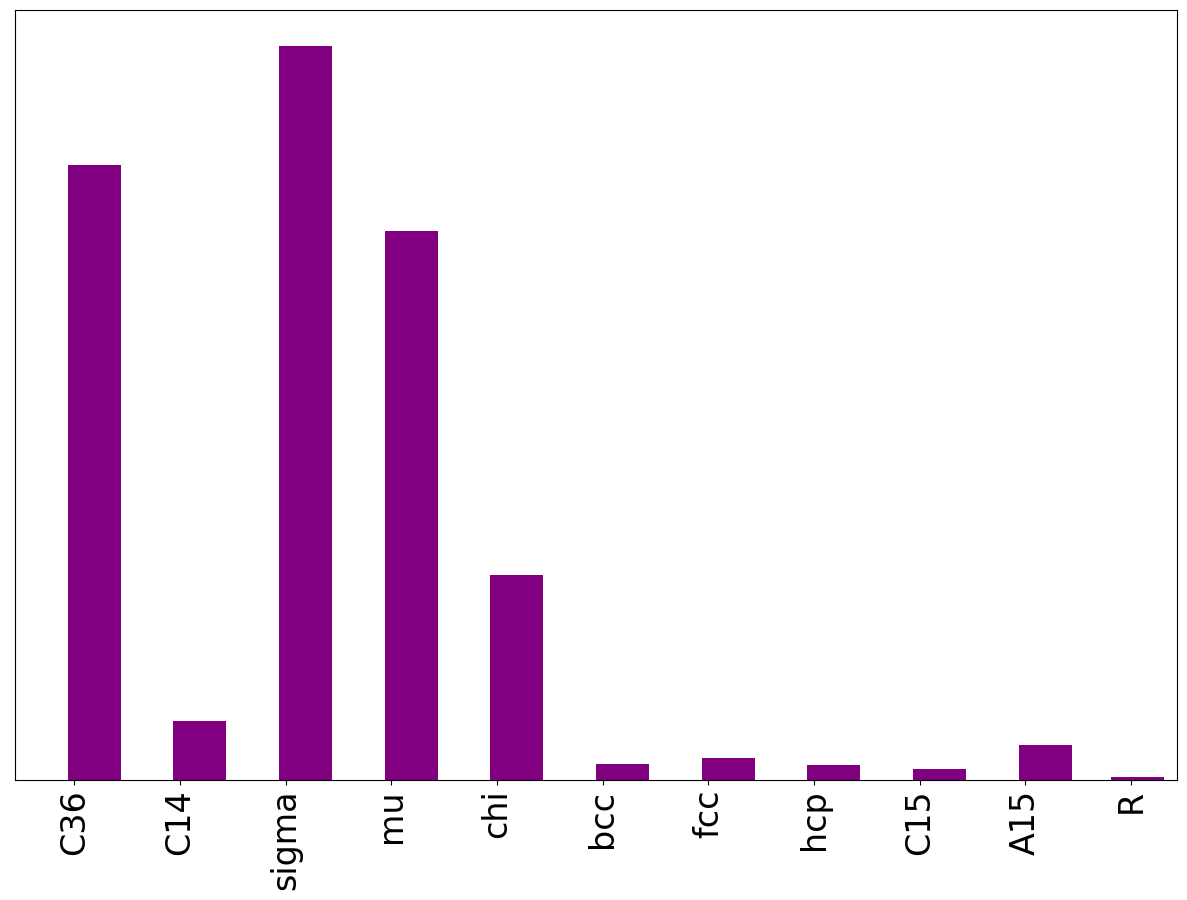

In [28]:
from BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'
Target_Class[Features.Struc == 'hcp'] = 'hcp'
Target_Class[Features.Struc == 'bcc'] = 'bcc'
Target_Class[Features.Struc == 'fcc'] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-fcc')] = 'fcc'
Target_Class[Features.Struc.str.contains('SQS-L12')] = 'fcc'
Target_Class[Features.Struc.str.contains('sigma_')] = 'sigma'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'

plt.hist(Target_Class, bins=80, density = True, width=0.5, align='left', color = 'purple')
plt.xticks(rotation=90); yticks = plt.yticks([])
plt.ylabel('')

## Class Weights

In [29]:
Classes = pd.DataFrame(Target_Class.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class.value_counts()
Classes['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()

In [30]:
data_w_classes =pd.concat([DATA,Classes['Class'].loc[DATA.index]], axis=1) 

# Finally some Machine Learning

[![scikit-logo](https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png#background-color:"#FFFFFF")](https://scikit-learn.org/stable/) is a standard tool for machine learning in python. The documentation in their webpage is often a good refference for tutorials, methods and Theory of Machine Learning. 

In [31]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso

## Feature Selection 

In [32]:
from sklearn.feature_selection import  (RFECV, 
    SelectKBest, 
    SequentialFeatureSelector,
    mutual_info_regression
)

In [33]:
from sklearn.model_selection import GridSearchCV

## Helper Functions

In [34]:
def plot_the_errors(THISERRORS,thecase):
    alltheclases = np.unique(Classes['Class'])
    thebadclasses = ['hcp', 'bcc', 'fcc','others','delta','R','C15']
    thegoodclases = [c for c in alltheclases if c not in thebadclasses ]
    fig, ax = plt.subplots(len(thegoodclases),1, sharex=True, figsize =(10,2*len(thegoodclases)))
    for i, classes in enumerate(thegoodclases) :
        thiserrors = np.abs(THISERRORS[Classes['Class']==classes])
        e = ax[i].hist (thiserrors, density=False, bins=100, label=classes)
        ax[i].annotate(classes, (0.8,0.5),xycoords = 'axes fraction', fontsize=20)
#    ax[-1].set_xlim([-0.01,1.0])
    ax[-1].set_ylabel('Density Counts',y=4), plt.xlabel('$|  E_F^{predicted} -  E_F^{True} | $')
    fig.tight_layout()
    fig.savefig(FileNames.get_plot_filename('Errors_by_class', thecase))
#    fig.savefig('graphs/Errors_by_class_{}_{}_{}_{}.pdf'.format(case, CASE, MODEL, CUTOFF))
    

def plot_the_prediction_line(theprediction, thepredictionovertest, thecase):
    fig, ax = plt.subplots()
    ax.plot(theprediction, DATA[TARGET],'o', label='full dataset')
    ax.plot(thepredictionovertest, Y_test,'o', label='test set')
    ax.plot(DATA[TARGET], DATA[TARGET],'-k')
    ax.legend()
    ax.set_xlabel('True')# $\Delta E_F$')
    ax.set_ylabel('predicted')# $\Delta E_F$')
    fig.savefig(FileNames.get_plot_filename('Predictionline',thecase))
#    fig.savefig('graphs/predictionline_{}_{}.pdf'.format(themodel,CASE, MODEL, CUTOFF))

def train_test_errors(themodel, Xtrain, Xtest, Ytrain, Ytest):
    Ypredict_train = themodel.predict(Xtrain)
    Ypredict_test = themodel.predict(Xtest)
    return {'train': mean_squared_error(Ytrain, Ypredict_train ,squared=False), 'test':  mean_squared_error(Ytest, Ypredict_test,squared=False )}

def make_simple_pipe(model, with_scaler = True):
        if with_scaler:
            return Pipeline([('scaler',MinMaxScaler()),('regressor', model())])
        else:
            return Pipeline([('regressor', model())])

# Train test split 

In [35]:
X_train, X_test, w_train, w_test,  Y_train, Y_test = train_test_split(DATA[real_feature],Classes['Weights'], DATA[TARGET],test_size=0.2, shuffle=True)

I need Lists of errors to compare methods

In [36]:
mses = {}

I also need to remove targets from feature names

## simple regressor - random forest

In [37]:
simple_model = make_simple_pipe(RandomForestRegressor)

In [38]:
simple_model.fit(X_train,Y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('regressor', RandomForestRegressor())])

In [39]:
mses['random forest regressor'] = train_test_errors(simple_model, X_train, X_test,Y_train, Y_test)

In [40]:
mses

{'random forest regressor': {'train': 0.05132177691412356,
  'test': 0.08032705931451181}}

In [41]:
simple_model_noscaler = make_simple_pipe(RandomForestRegressor, with_scaler=False)

In [42]:
simple_model_noscaler.fit(X_train, Y_train)

Pipeline(steps=[('regressor', RandomForestRegressor())])

In [43]:
mses['random forest regressor noscale'] = train_test_errors(simple_model_noscaler, X_train, X_test, Y_train, Y_test)

In [44]:
mses

{'random forest regressor': {'train': 0.05132177691412356,
  'test': 0.08032705931451181},
 'random forest regressor noscale': {'train': 0.05137765373429098,
  'test': 0.08085024491749254}}

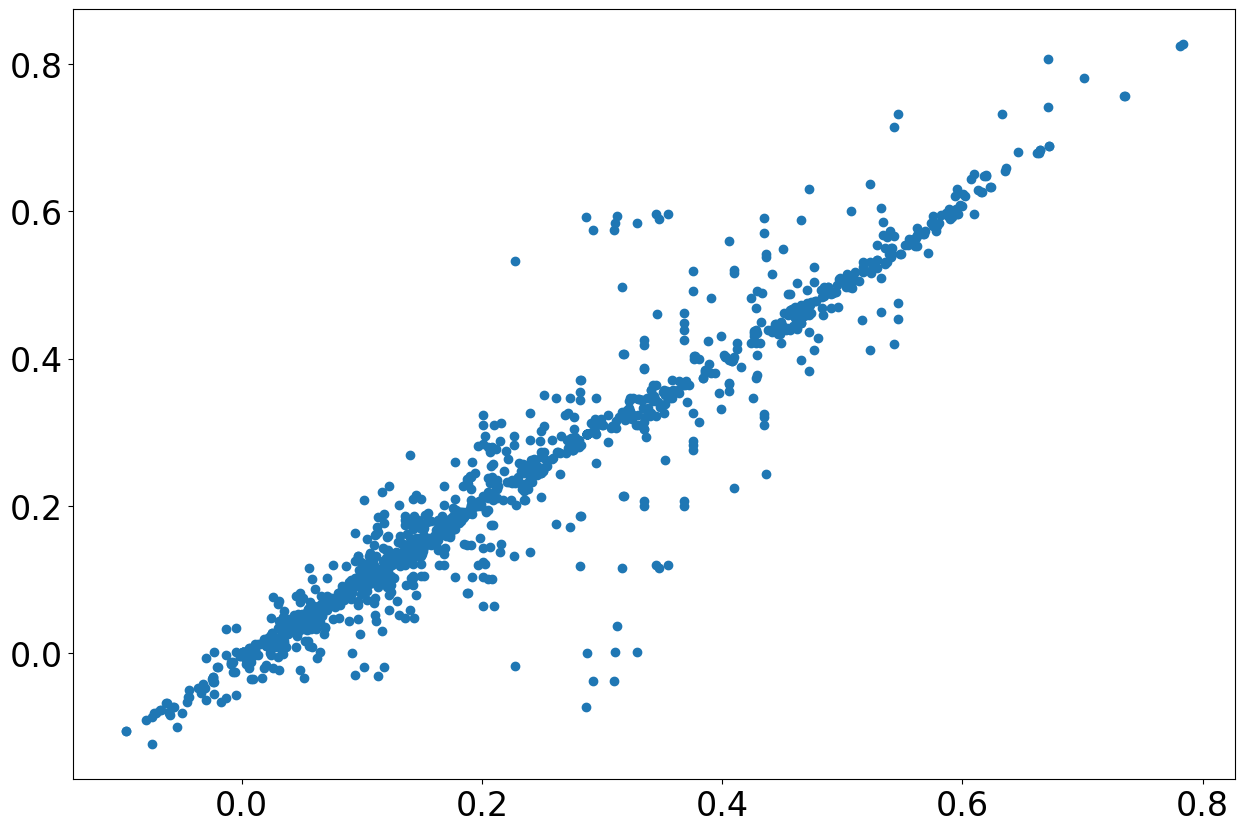

In [45]:
plt.plot(simple_model.predict(X_train),Y_train,'o')
#plt.plot(simple_model_noscaler.predict(X_train),Y_train,'o')

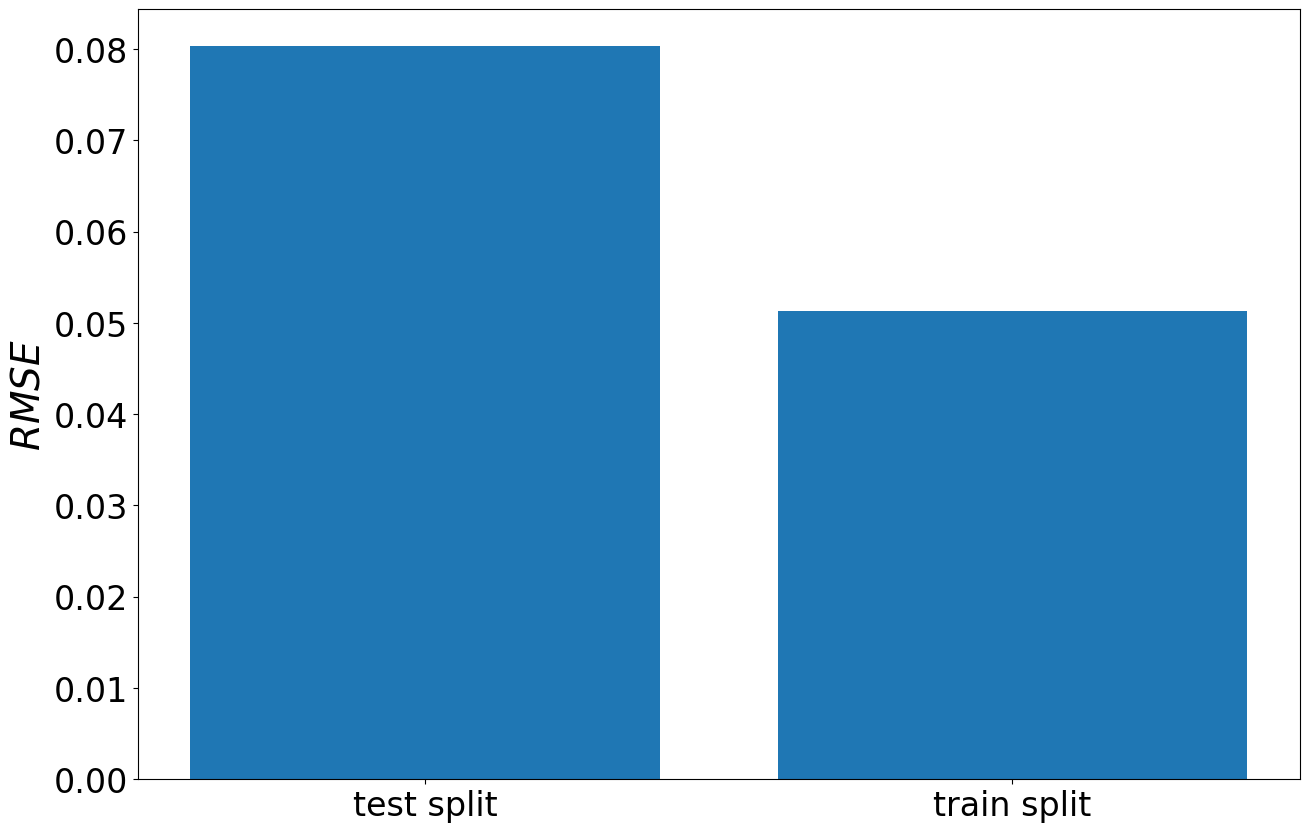

In [46]:
plt.bar(['test split','train split'],[mses['random forest regressor']['test'], mses['random forest regressor']['train']])
label = plt.ylabel('$RMSE$')

In [47]:
YPREDICT = simple_model.predict(DATA[real_feature])
Y_predict_test = simple_model.predict(X_test)
ERRORS = (YPREDICT - DATA[TARGET]).map(np.abs)

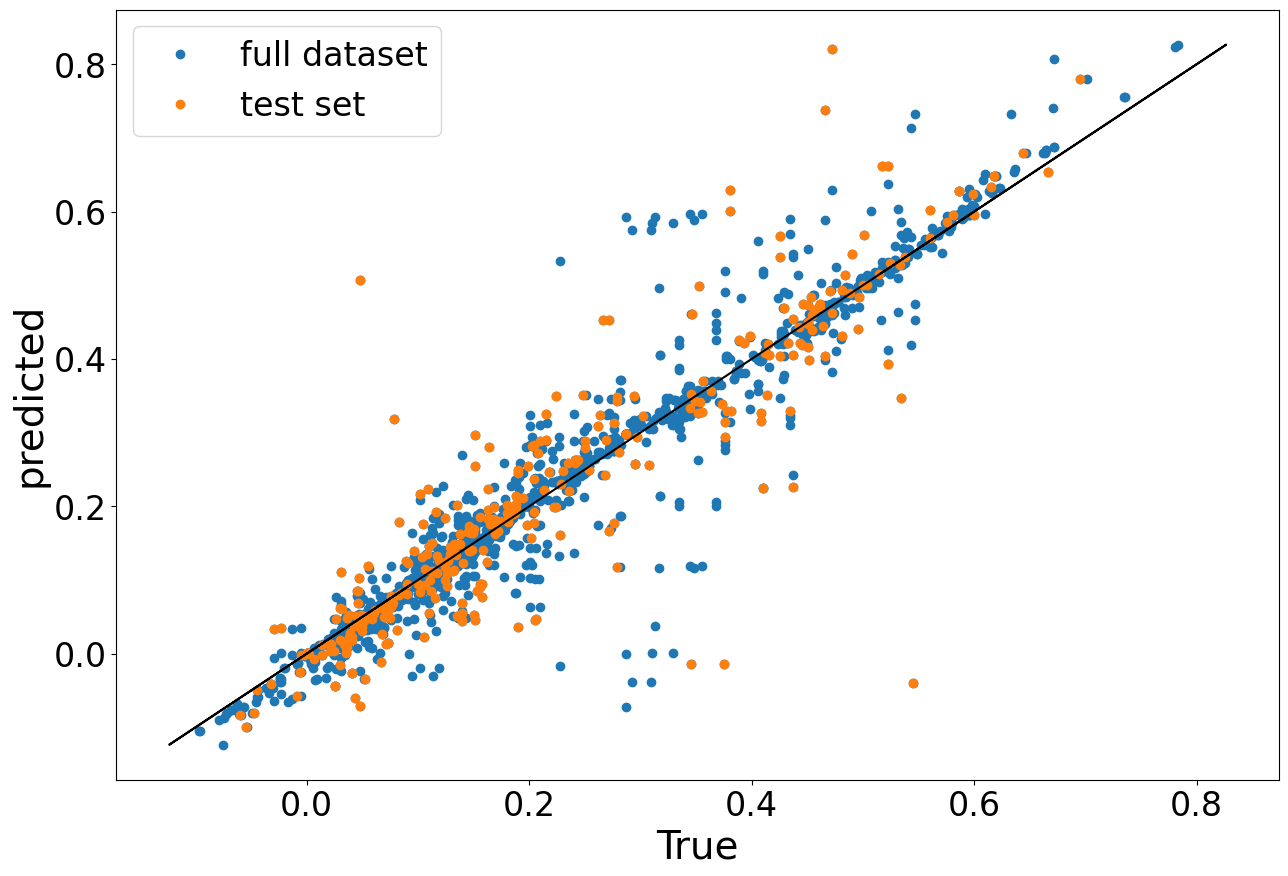

In [48]:
plot_the_prediction_line(YPREDICT, Y_predict_test, 'RandomForestRegressor')

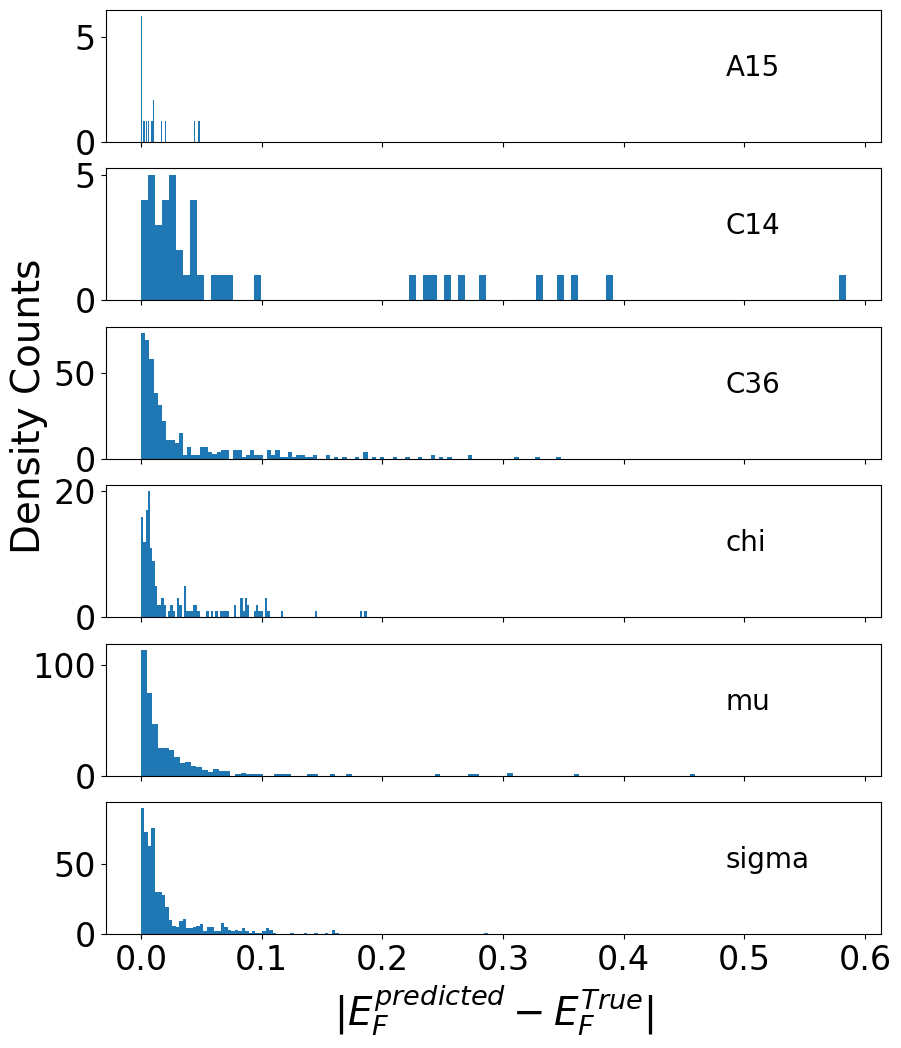

In [49]:
plot_the_errors(ERRORS,'RandomForestRegressor')

In [50]:
ERRORS[ERRORS > 0.35]

Co_pv6W_sv7.mu-BABBB.NM    0.359809
Co_pv7W_sv6.mu-ABAAA.NM    0.459498
Co_pv8W_sv4.C14-BAA.NM     0.583866
Cr_pv8W_sv4.C14-BAA.FM     0.358925
Cr_pv8W_sv4.C14-BAA.NM     0.388106
Name: EF, dtype: float64

There is a big variety of regression methods available in scikit-learn package.
[See the documentation](https://scikit-learn.org/stable/supervised_learning.html#supervised-learninghttps://scikit-learn.org/stable/supervised_learning.html#supervised-learning)

# Feature Selection

## Random Forest + selectkbest

In [51]:
useful_feature = []
for key in useful.keys():
    useful_feature+=useful[key]

In [52]:
Selector = SelectKBest(mutual_info_regression, k=10)
Selector.fit(X_train[useful_feature], Y_train)

SelectKBest(score_func=<function mutual_info_regression at 0x7f763022f1f0>)

In [53]:
simple_model = RandomForestRegressor()

In [54]:
np.array(useful_feature)[Selector.get_support()]

array(['all_NSC_an_4', 'all_NSC_bn_5', 'all_NSC_bn_7',
       'all_NSC_moments_4', 'all_NSC_moments_5', 'all_NSC_moments_6',
       'all_NSC_moments_8', 'all_NSC_moments_9', 'all_NSC_moments_10',
       'all_NSC_moments_11'], dtype='<U21')

In [55]:
simple_model.fit(X_train[np.array(useful_feature)[Selector.get_support()]], Y_train)

RandomForestRegressor()

In [56]:
Y_predict = simple_model.predict(X_train[np.array(useful_feature)[Selector.get_support()]])

mses['simplekbest'] = {'train': mean_squared_error(Y_train, Y_predict, squared=False)}

Y_test_predict = simple_model.predict(X_test[np.array(useful_feature)[Selector.get_support()]])

mses['simplekbest'].update({'test': mean_squared_error(Y_test, Y_test_predict,squared=False)})

In [57]:
mses

{'random forest regressor': {'train': 0.05132177691412356,
  'test': 0.08032705931451181},
 'random forest regressor noscale': {'train': 0.05137765373429098,
  'test': 0.08085024491749254},
 'simplekbest': {'train': 0.05468431884123509, 'test': 0.08912501625331715}}

### on a pipeline

In [58]:
RF_SelectKbest = Pipeline(
    [
        ('feature_selection', SelectKBest()),
        ('regression', RandomForestRegressor())
    ]
)

In [59]:
RF_SelectKbest.fit(X_train, Y_train)

Pipeline(steps=[('feature_selection', SelectKBest()),
                ('regression', RandomForestRegressor())])

In [60]:
Y_predict_Pipe  = RF_SelectKbest.predict(X_train)

mses['RF_SK_Pipe'] = {'train': mean_squared_error(Y_train, Y_predict_Pipe, squared=False) }

Y_test_predict_Pipe = RF_SelectKbest.predict(X_test)

mses['RF_SK_Pipe'].update({'test': mean_squared_error(Y_test, Y_test_predict_Pipe, squared=False)})

In [61]:
np.array(real_feature)[RF_SelectKbest[0].get_support()]

array(['CN16_b_NSC_SIGMA_13', 'CN16_b_NSC_SIGMA_14', 'CN12_c_NSC_Ainf_0',
       'CN13_a_NSC_Ainf_0', 'CN16_a_NSC_Ainf_0', 'CN16_b_NSC_Ainf_0',
       'CN12_c_NSC_Binf_0', 'CN13_a_NSC_Binf_0', 'CN16_a_NSC_Binf_0',
       'CN16_b_NSC_Binf_0'], dtype='<U29')

In [62]:
mses

{'random forest regressor': {'train': 0.05132177691412356,
  'test': 0.08032705931451181},
 'random forest regressor noscale': {'train': 0.05137765373429098,
  'test': 0.08085024491749254},
 'simplekbest': {'train': 0.05468431884123509, 'test': 0.08912501625331715},
 'RF_SK_Pipe': {'train': 0.08410436505422667, 'test': 0.10435513058451122}}

### with cross validation

In [73]:
Params= {'feature_selection__k':np.arange(10,30), 'regression__max_depth':[20]} #,1, 2,3,4,5,6,7,8,9]} #, 'regression__alpha':[0.01, 0.1,1]}

In [74]:
Validator = GridSearchCV(RF_SelectKbest,Params, refit=True, scoring='neg_root_mean_squared_error',verbose=5,n_jobs=2)

In [75]:
Validator.fit(X_train, Y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(estimator=Pipeline(steps=[('feature_selection', SelectKBest()),
                                       ('regression',
                                        RandomForestRegressor())]),
             n_jobs=2,
             param_grid={'feature_selection__k': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29]),
                         'regression__max_depth': [20]},
             scoring='neg_root_mean_squared_error', verbose=5)

In [76]:
Validator.best_estimator_

Pipeline(steps=[('feature_selection', SelectKBest(k=29)),
                ('regression', RandomForestRegressor(max_depth=20))])

In [77]:
fitted_best_estimator = Validator.best_estimator_.fit(X_train, Y_train)

In [78]:
x = Validator.cv_results_['param_feature_selection__k'].data

In [79]:
y = Validator.cv_results_['mean_test_score']

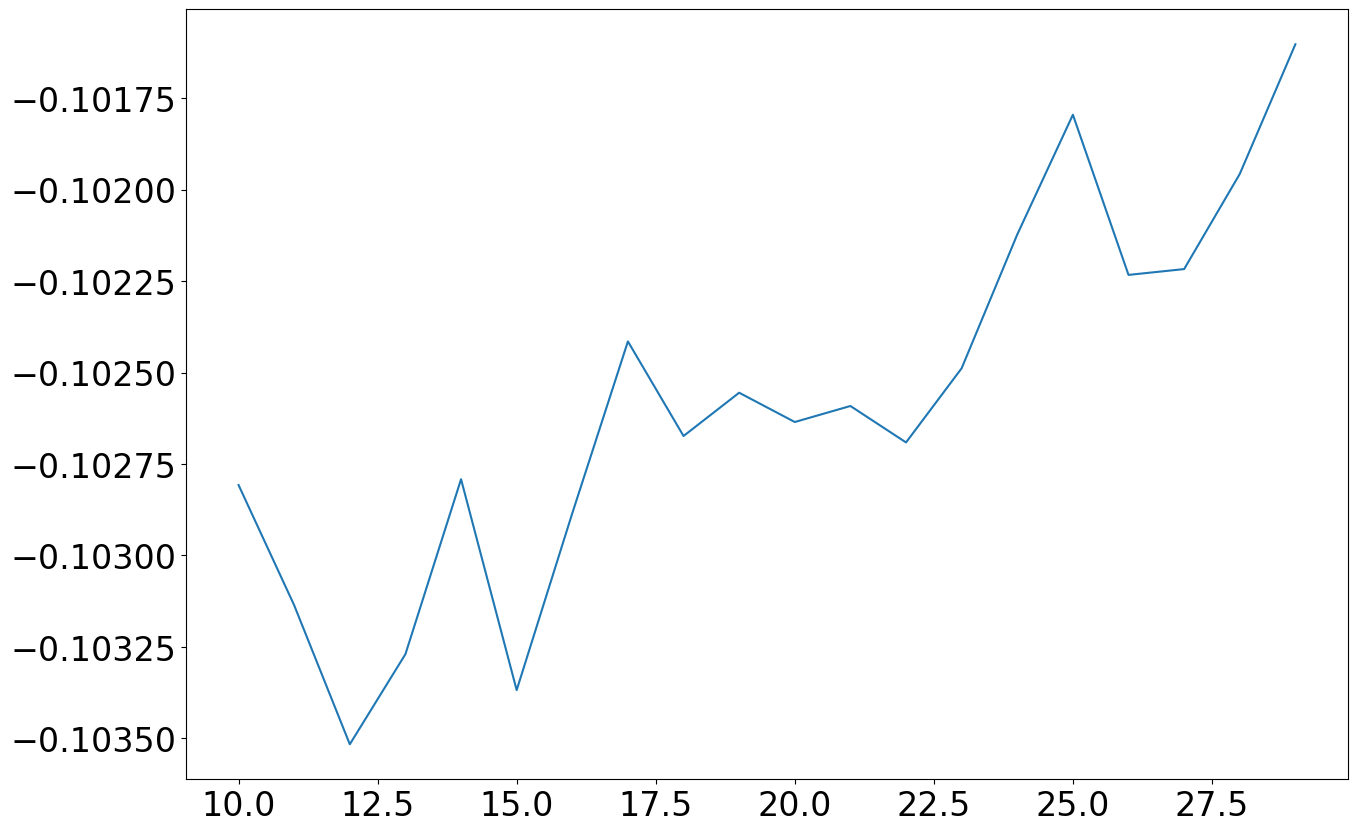

In [80]:
plt.plot(x,y)

In [81]:
np.array(real_feature)[Validator.best_estimator_[0].get_support()]

array(['CN16_a_NSC_SIGMA_9', 'CN16_a_NSC_SIGMA_10', 'CN16_a_NSC_SIGMA_11',
       'CN16_a_NSC_SIGMA_12', 'CN16_a_NSC_SIGMA_13',
       'CN16_a_NSC_SIGMA_14', 'CN16_b_NSC_SIGMA_0', 'CN16_b_NSC_SIGMA_1',
       'CN16_b_NSC_SIGMA_2', 'CN16_b_NSC_SIGMA_3', 'CN16_b_NSC_SIGMA_4',
       'CN16_b_NSC_SIGMA_5', 'CN16_b_NSC_SIGMA_6', 'CN16_b_NSC_SIGMA_7',
       'CN16_b_NSC_SIGMA_8', 'CN16_b_NSC_SIGMA_9', 'CN16_b_NSC_SIGMA_10',
       'CN16_b_NSC_SIGMA_11', 'CN16_b_NSC_SIGMA_12',
       'CN16_b_NSC_SIGMA_13', 'CN16_b_NSC_SIGMA_14', 'CN12_c_NSC_Ainf_0',
       'CN13_a_NSC_Ainf_0', 'CN16_a_NSC_Ainf_0', 'CN16_b_NSC_Ainf_0',
       'CN12_c_NSC_Binf_0', 'CN13_a_NSC_Binf_0', 'CN16_a_NSC_Binf_0',
       'CN16_b_NSC_Binf_0'], dtype='<U29')

## just in a loop

In [82]:
RF_SelectKbest

Pipeline(steps=[('feature_selection', SelectKBest()),
                ('regression', RandomForestRegressor())])

In [83]:
for k in range(20,30):
#    model = Pipeline([
#        ('feature_selection', SelectKBest(k=k)),
#        ('regression', RandomForestRegressor(max_depth=20))
#    ])
    Params = {'feature_selection__k': [k]}
    model = GridSearchCV(RF_SelectKbest,param_grid=Params,scoring='neg_root_mean_squared_error')
    model.fit(X_train, Y_train)
    mask = model.best_estimator_[0].get_support()
    importances = model.best_estimator_[1].feature_importances_
    print(k, np.array(real_feature)[mask][:3], importances[:3], model.cv_results_['mean_test_score'])
#    print(k, real_feature[model[0].get_support()])

20 ['CN16_b_NSC_SIGMA_3' 'CN16_b_NSC_SIGMA_4' 'CN16_b_NSC_SIGMA_5'] [0.01222758 0.00407448 0.00821589] [-0.1028335]
21 ['CN16_b_NSC_SIGMA_2' 'CN16_b_NSC_SIGMA_3' 'CN16_b_NSC_SIGMA_4'] [0.00477131 0.0108545  0.00496217] [-0.10240662]
22 ['CN16_b_NSC_SIGMA_1' 'CN16_b_NSC_SIGMA_2' 'CN16_b_NSC_SIGMA_3'] [0.01171521 0.00356866 0.00783432] [-0.10195183]
23 ['CN16_b_NSC_SIGMA_0' 'CN16_b_NSC_SIGMA_1' 'CN16_b_NSC_SIGMA_2'] [0.00041571 0.00936614 0.00441179] [-0.10264279]
24 ['CN16_a_NSC_SIGMA_14' 'CN16_b_NSC_SIGMA_0' 'CN16_b_NSC_SIGMA_1'] [0.03630857 0.00013198 0.01139339] [-0.10240404]
25 ['CN16_a_NSC_SIGMA_13' 'CN16_a_NSC_SIGMA_14' 'CN16_b_NSC_SIGMA_0'] [3.56674238e-02 2.97345659e-02 9.75856539e-05] [-0.10244885]
26 ['CN16_a_NSC_SIGMA_12' 'CN16_a_NSC_SIGMA_13' 'CN16_a_NSC_SIGMA_14'] [0.02756301 0.03036779 0.02448757] [-0.10182613]
27 ['CN16_a_NSC_SIGMA_11' 'CN16_a_NSC_SIGMA_12' 'CN16_a_NSC_SIGMA_13'] [0.0329183  0.02280697 0.01991059] [-0.10185041]
28 ['CN16_a_NSC_SIGMA_10' 'CN16_a_NSC_SIGMA_

In [84]:
Y_test_predict = fitted_best_estimator.predict(X_test)

Y_train_predict = fitted_best_estimator.predict(X_train)

mses['RF_SK_pipe'] ={'test':mean_squared_error(Y_test, Y_test_predict,squared=False)}

mses['RF_SK_pipe'].update({'train':mean_squared_error(Y_train, Y_train_predict, squared=False)})

In [85]:
mses

{'random forest regressor': {'train': 0.05132177691412356,
  'test': 0.08032705931451181},
 'random forest regressor noscale': {'train': 0.05137765373429098,
  'test': 0.08085024491749254},
 'simplekbest': {'train': 0.05468431884123509, 'test': 0.08912501625331715},
 'RF_SK_Pipe': {'train': 0.08410436505422667, 'test': 0.10435513058451122},
 'RF_SK_pipe': {'test': 0.1041687620379649, 'train': 0.08400887085725724}}

## Ranod Forest + Sequential Selection

This is the same as the FeatureConcatenation I implemented, but the output doesnt tell which feature is most important and doesnt let you fix any feature

In [86]:
SeqSelector = SequentialFeatureSelector(
    RandomForestRegressor(),
    n_features_to_select=10, n_jobs=3, 
    scoring='neg_root_mean_squared_error')

In [ ]:
SeqSelector.fit(X_train, Y_train)

In [ ]:
SeqSelector

In [155]:
X_train.columns[SeqSelector.get_support()]

Index(['CN15_a_NSC_U_bond_atom_list_0', 'all_NSC_moments_7',
       'CN12_c_NSC_moments_6', 'CN14_a_NSC_moments_6', 'CN16_a_NSC_moments_3',
       'all_NSC_an_2', 'CN15_a_NSC_an_2', 'CN14_a_NSC_bn_3', 'CN16_b_NSC_bn_7',
       'CN12_c_NSC_Binf_0'],
      dtype='object')

In [169]:
features = X_train.columns[SeqSelector.get_support()]

In [165]:
features

Index(['CN15_a_NSC_U_bond_atom_list_0', 'all_NSC_moments_7',
       'CN12_c_NSC_moments_6', 'CN14_a_NSC_moments_6', 'CN16_a_NSC_moments_3',
       'all_NSC_an_2', 'CN15_a_NSC_an_2', 'CN14_a_NSC_bn_3', 'CN16_b_NSC_bn_7',
       'CN12_c_NSC_Binf_0'],
      dtype='object')

In [160]:
allfeatures = features.append( pd.Index(['MagConfig_0']))

In [170]:
allfeatures

Index(['CN15_a_NSC_U_bond_atom_list_0', 'all_NSC_moments_7',
       'CN12_c_NSC_moments_6', 'CN14_a_NSC_moments_6', 'CN16_a_NSC_moments_3',
       'all_NSC_an_2', 'CN15_a_NSC_an_2', 'CN14_a_NSC_bn_3', 'CN16_b_NSC_bn_7',
       'CN12_c_NSC_Binf_0', 'MagConfig_0'],
      dtype='object')

In [166]:
model = RandomForestRegressor(max_depth=20)

In [171]:
model.fit(X_train[features], Y_train)

RandomForestRegressor(max_depth=20)

In [172]:
mses['RF_After_SeqSelection'] = {
    'test': mean_squared_error(Y_test, model.predict(X_test[allfeatures]),squared=False),
    'train': mean_squared_error(Y_train, model.predict(X_train[allfeatures]),squared=False)
}

KeyError: "['MagConfig_0'] not in index"

In [173]:
mses

{'random forest regressor': {'train': 0.043013458237797814,
  'test': 0.10302987180207698},
 'random forest regressor noscale': {'train': 0.043095786636324566,
  'test': 0.10292421435889319},
 'simplekbest': {'train': 0.04651684508933487, 'test': 0.10781101798105723},
 'RF_SK_Pipe': {'train': 0.0815069225912351, 'test': 0.11160048112212023},
 'RF_SK_pipe': {'test': 0.11184631601134992, 'train': 0.08099223640013672}}

In [174]:
model.feature_importances_

array([0.01460506, 0.62301612, 0.01805133, 0.02758966, 0.15790051,
       0.06144014, 0.01860735, 0.02287535, 0.02997335, 0.02594113])

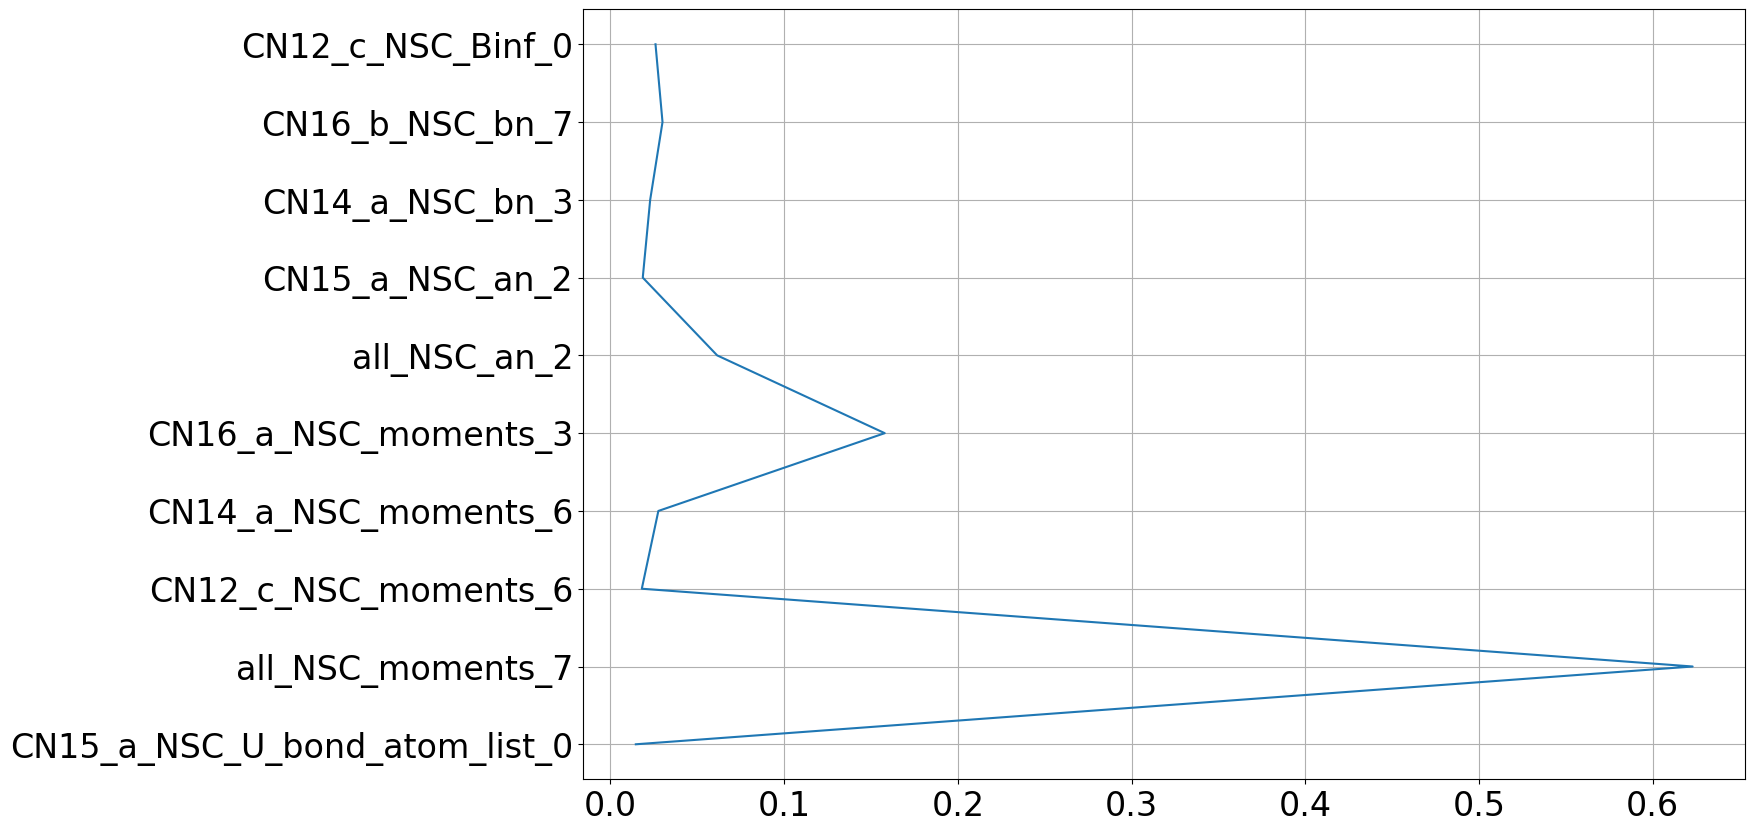

In [176]:
fig, ax = plt.subplots()
ax.plot( model.feature_importances_, features,)
labels = ax.get_xticklabels()
ax.grid('on')
#ax.set_xticklabels(labels, rotation=90)
#fig.tight_layout()

## Random Forest + recursive feature elumination with CV

In [416]:
Selector = RFECV (RandomForestRegressor(), min_features_to_select=10, 
                 scoring='neg_root_mean_squared_error', verbose=5, n_jobs=3)

In [417]:
Selector.fit(X_train, Y_train)

Fitting estimator with 63 features.
Fitting estimator with 62 features.
Fitting estimator with 61 features.
Fitting estimator with 60 features.
Fitting estimator with 59 features.
Fitting estimator with 58 features.
Fitting estimator with 57 features.
Fitting estimator with 56 features.
Fitting estimator with 55 features.
Fitting estimator with 54 features.
Fitting estimator with 53 features.
Fitting estimator with 52 features.
Fitting estimator with 51 features.
Fitting estimator with 50 features.
Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 fe

RFECV(estimator=RandomForestRegressor(), min_features_to_select=10, n_jobs=3,
      scoring='neg_root_mean_squared_error', verbose=5)

In [418]:
import joblib

In [419]:
joblib.dump(Selector, 'SelectorRFECV')

['SelectorRFECV']

In [426]:
Selector.support_

array([ True,  True, False, False, False,  True, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True, False, False,  True,  True,
       False,  True,  True,  True,  True, False,  True, False,  True,
        True, False, False, False, False,  True,  True,  True,  True,
       False, False,  True,  True, False, False,  True, False,  True,
       False, False, False,  True,  True, False, False,  True, False])

In [427]:
Selector.grid_scores_

array([-0.08891986, -0.09004453, -0.08948214, -0.0895475 , -0.08952481,
       -0.08960112, -0.08912361, -0.08959153, -0.08928002, -0.08917701,
       -0.08901059, -0.09007603, -0.08894723, -0.08881313, -0.08927792,
       -0.08938189, -0.088698  , -0.09049032, -0.0950654 , -0.09452273,
       -0.09486721, -0.09645292, -0.09675677, -0.09692066, -0.09661929,
       -0.09667918, -0.09658905, -0.09687712, -0.09736483, -0.09736234,
       -0.09712299, -0.09625741, -0.09753467, -0.09756019, -0.09654441,
       -0.09627024, -0.09667207, -0.09676358, -0.09658899, -0.09713444,
       -0.09662819, -0.09647105, -0.09724233, -0.0964937 , -0.09710172,
       -0.09666671, -0.0976723 , -0.09613286, -0.0972149 , -0.09629178,
       -0.09650623, -0.09644761, -0.09640307, -0.09653503])

In [435]:
thisfeatures = X_train.columns[Selector.support_]

In [436]:
order = np.argsort(Selector.estimator_.feature_importances_)

In [437]:
thisfeatures[order]

Index(['NSC_an_1', 'NSC_an_7', 'NSC_SIGMA_15', 'NSC_an_8', 'NSC_SIGMA_16',
       'NSC_SIGMA_13', 'NSC_an_2', 'NSC_SIGMA_5', 'NSC_moments_4', 'NSC_an_3',
       'NSC_SIGMA_10', 'NSC_SIGMA_1', 'NSC_SIGMA_6', 'NSC_moments_0',
       'NSC_moments_8', 'NSC_SIGMA_2', 'NSC_SIGMA_11', 'NSC_SIGMA_9',
       'NSC_an_4', 'NSC_SIGMA_8', 'NSC_U_bind_0', 'NSC_bn_8', 'NSC_bn_2',
       'NSC_Binf_0', 'NSC_bn_9', 'NSC_bn_4'],
      dtype='object')

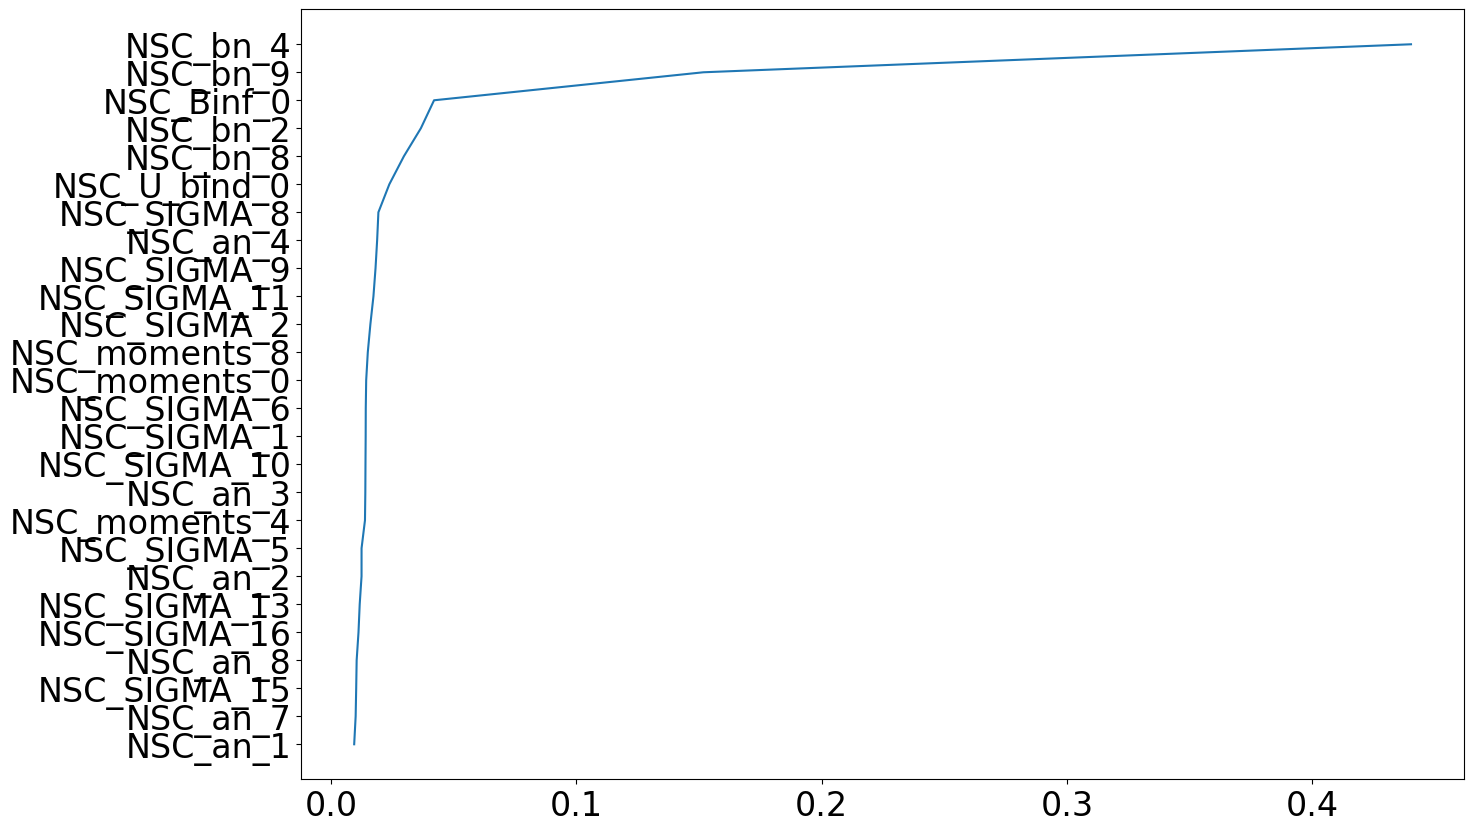

In [438]:
plt.plot(Selector.estimator_.feature_importances_[order], thisfeatures[order])

# My Old Feature Concatenation 

In [97]:
# This is the standard way to import modules
del FeatureConcatenate
# from BopFoxFeaturizer.FeatureConcatenate import FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate

#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
FC['RandomForest'] = FeatureConcatenate(
    #pd.concat([X_train, Y_train['EF']], axis=1), #DATA, 
    DATA[real_feature+[TARGET]],
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=real_feature,
    data_target=TARGET,
    criterion = C_RITERION,
    sort_criteria='score_only'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest'], Bestscores['RandomForest'] = FC['RandomForest'].build_features_list(
    best_feature_proposal=['MagConfig_0'],  #,'NSC_U_bind_0'],
    maxnumfeatures=10,
    pass_force_refit=True,
    report_prefix='RandomForest_'+CASE
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.37it/s]
procesing '['MagConfig_0']' with 'NSC_moments_5' ... ::   0%|                                    | 0/32 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.19138368953575915
Refitting ..


procesing '['MagConfig_0']' with 'NSC_moments_8' ... :: 100%|###########################| 32/32 [00:41<00:00,  1.29s/it]


...

fitting has finished,  test_score  =  0.0902430071188683


procesing '['MagConfig_0', 'NSC_moments_9', 'NSC_moments_0', 'NSC_SIGMA_9', 'NSC_SIGMA_8', 'NSC_SIGMA_1', 'NSC_U_bind_0'

Refitting ..


procesing '['MagConfig_0', 'NSC_moments_9', 'NSC_moments_0', 'NSC_SIGMA_9', 'NSC_SIGMA_8', 'NSC_SIGMA_1', 'NSC_U_bind_0'

fitting has finished,  test_score  =  0.08604397964426413


In [98]:
FileNames = SourceFileLoader('FileNames','Tools.py').load_module().CaseNamer(CASE, MODEL, CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE,TARGET=TARGET)

In [99]:
thisdata = pd.DataFrame(np.array([[x, y] for x, y in zip(Bestfeats['RandomForest'], Bestscores['RandomForest'])]))

In [100]:
thisdata.to_csv(
    FileNames.get_table_filename('BopFeatures_Ubind',FC['RandomForest'].sort_criteria),
    header=False, index=False
)

In [101]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_an'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'an' in f or 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_an'], Bestscores['RandomForest_an'] = \
    FC['RandomForest_an'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_an_'+CASE,
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.41it/s]
procesing '['MagConfig_0']' with 'NSC_bn_5' ... ::   0%|                                         | 0/10 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.18779638784633967
Refitting ..


procesing '['MagConfig_0']' with 'NSC_bn_2' ... :: 100%|################################| 10/10 [00:11<00:00,  1.15s/it]


fitting has finished,  test_score  =  0.11402280481492093


procesing '['MagConfig_0', 'NSC_bn_5']' with 'NSC_an_2' ... ::   0%|                              | 0/5 [00:00<?, ?it/s]

Refitting ..


procesing '['MagConfig_0', 'NSC_bn_5']' with 'NSC_an_3' ... :: 100%|######################| 5/5 [00:07<00:00,  1.40s/it]


fitting has finished,  test_score  =  0.10139636084630904


In [102]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_bn'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'bn' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_bn'], Bestscores['RandomForest_bn'] = FC['RandomForest_bn'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_bn_'+CASE,
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.44it/s]
procesing '['MagConfig_0']' with 'NSC_bn_5' ... ::   0%|                                          | 0/5 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.18776051662729978
Refitting ..


procesing '['MagConfig_0']' with 'NSC_bn_2' ... :: 100%|##################################| 5/5 [00:05<00:00,  1.16s/it]


fitting has finished,  test_score  =  0.11436573435336986


In [103]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_sigma'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'SIGMA' in f],
    data_target=TARGET,
    criterion = criterion, sort_criteria='index_too'
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_sigma'], Bestscores['RandomForest_sigma'] = FC['RandomForest_sigma'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_sigma_'+CASE,
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.43it/s]
procesing '['MagConfig_0']' with 'NSC_SIGMA_3' ... ::   0%|                                       | 0/9 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.18780570017782267
Refitting ..


procesing '['MagConfig_0']' with 'NSC_SIGMA_9' ... :: 100%|###############################| 9/9 [00:10<00:00,  1.18s/it]
procesing '['MagConfig_0', 'NSC_SIGMA_5']' with 'NSC_SIGMA_3' ... ::   0%|                        | 0/7 [00:00<?, ?it/s]

...

Refitting ..


procesing '['MagConfig_0', 'NSC_SIGMA_5', 'NSC_SIGMA_1', 'NSC_SIGMA_2']' with 'NSC_SIGMA_9' ... :: 100%|#| 2/2 [00:03<00
procesing '['MagConfig_0', 'NSC_SIGMA_5', 'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_3']' with 'NSC_SIGMA_9' ... ::   0%| 

fitting has finished,  test_score  =  0.1191616123009749
Refitting ..


procesing '['MagConfig_0', 'NSC_SIGMA_5', 'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_3']' with 'NSC_SIGMA_9' ... :: 100%|#

fitting has finished,  test_score  =  0.11256231695097195


In [104]:
#param_grid = {'max_depth':np.arange(1,10) , 'min_samples_split':[2]}
param_grid = {}
del FeatureConcatenate
FeatureConcatenate = SourceFileLoader('FeatureConcate','/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/BopFoxFeaturizer/FeatureConcatenate.py'
                                     ).load_module().FeatureConcatenate


FC['RandomForest_moments'] = FeatureConcatenate(
    pd.concat([X_train, Y_train], axis=1), #DATA, 
    RandomForestRegressor(),
    model_params=param_grid,
    feature_list=[f for f in real_feature if 'moments' in f],
    data_target=TARGET,
    criterion = criterion
#    sample_weights = w_train, #Classes['Weights']
)

Bestfeats['RandomForest_moments'], Bestscores['RandomForest_moments'] = FC['RandomForest_moments'].build_features_list(
    best_feature_proposal=['MagConfig_0'],
    pass_force_refit=True,
    report_prefix='RandomForest_moments_'+CASE,
)

procesing '[]' with 'MagConfig_0' ... ::   0%|                                                    | 0/1 [00:00<?, ?it/s]

Refitting ..


procesing '[]' with 'MagConfig_0' ... :: 100%|############################################| 1/1 [00:00<00:00,  1.42it/s]
procesing '['MagConfig_0']' with 'NSC_moments_3' ... ::   0%|                                    | 0/10 [00:00<?, ?it/s]

fitting has finished,  test_score  =  0.18791522552668566
Refitting ..


procesing '['MagConfig_0']' with 'NSC_moments_4' ... :: 100%|###########################| 10/10 [00:11<00:00,  1.15s/it]


fitting has finished,  test_score  =  0.1363998153711789


procesing '['MagConfig_0', 'NSC_moments_9']' with 'NSC_moments_6' ... ::   0%|                    | 0/5 [00:00<?, ?it/s]

Refitting ..


procesing '['MagConfig_0', 'NSC_moments_9']' with 'NSC_moments_4' ... :: 100%|############| 5/5 [00:06<00:00,  1.39s/it]


fitting has finished,  test_score  =  0.09529035651465027


In [120]:
def plot_learning_curve(thescores, thefeatures, ax=None, modelname='RandomForest',dothelabels = True):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(np.arange(1,len(thescores)+1),thescores) 
    ax.set_ylabel ("RMSE "+C_RITERION)
    ax.set_xlabel ("number of features")
    if dothelabels:
        for i, feat in enumerate(thefeatures):
            t = plt.annotate(
                feature_titles[feat],
                ((i+1), thescores[i]),
                ((i+1), thescores[i]),
                fontsize=22,
            )
            t.set_bbox(dict(facecolor='white', alpha=0.5))

    plt.savefig(FileNames.get_plot_filename('LearningCurve', modelname))
    return ax

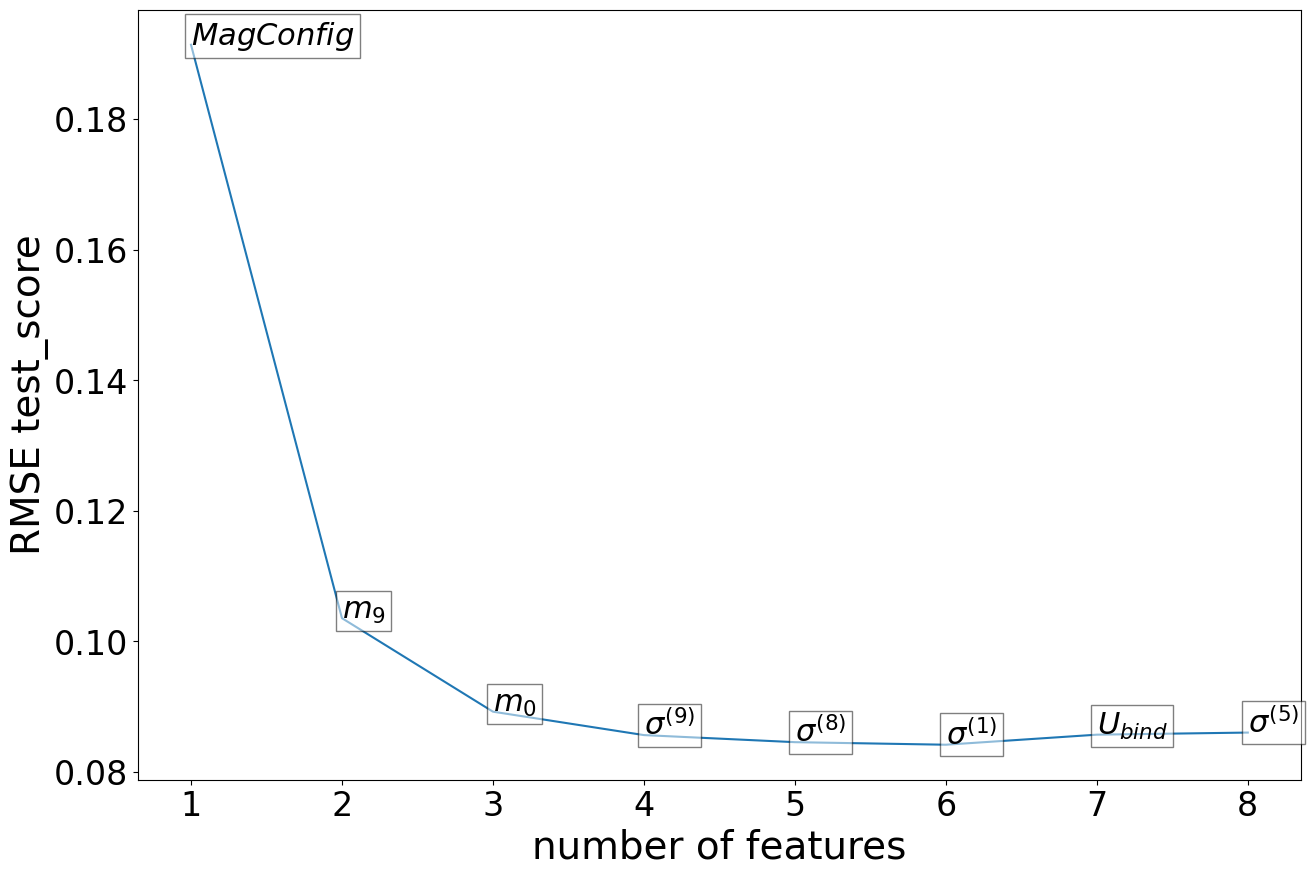

In [122]:
ax1 = plot_learning_curve(Bestscores['RandomForest'],Bestfeats['RandomForest'])
#ax2 = plot_learning_curve(Bestscores['RandomForest_an'],Bestfeats['RandomForest_an'], ax=ax1)
#ax2 = plot_learning_curve(Bestscores['RandomForest_moments'],Bestfeats['RandomForest_moments'], ax=ax1)

In [123]:
feature_titles = feature_titles[feature_titles  != '']

# The Errors

In [124]:
YPREDICT = FC['RandomForest'].report['best_estimator'].iloc[-1].predict(DATA[Bestfeats['RandomForest']])
EPREDICT = np.abs(YPREDICT - DATA[TARGET])

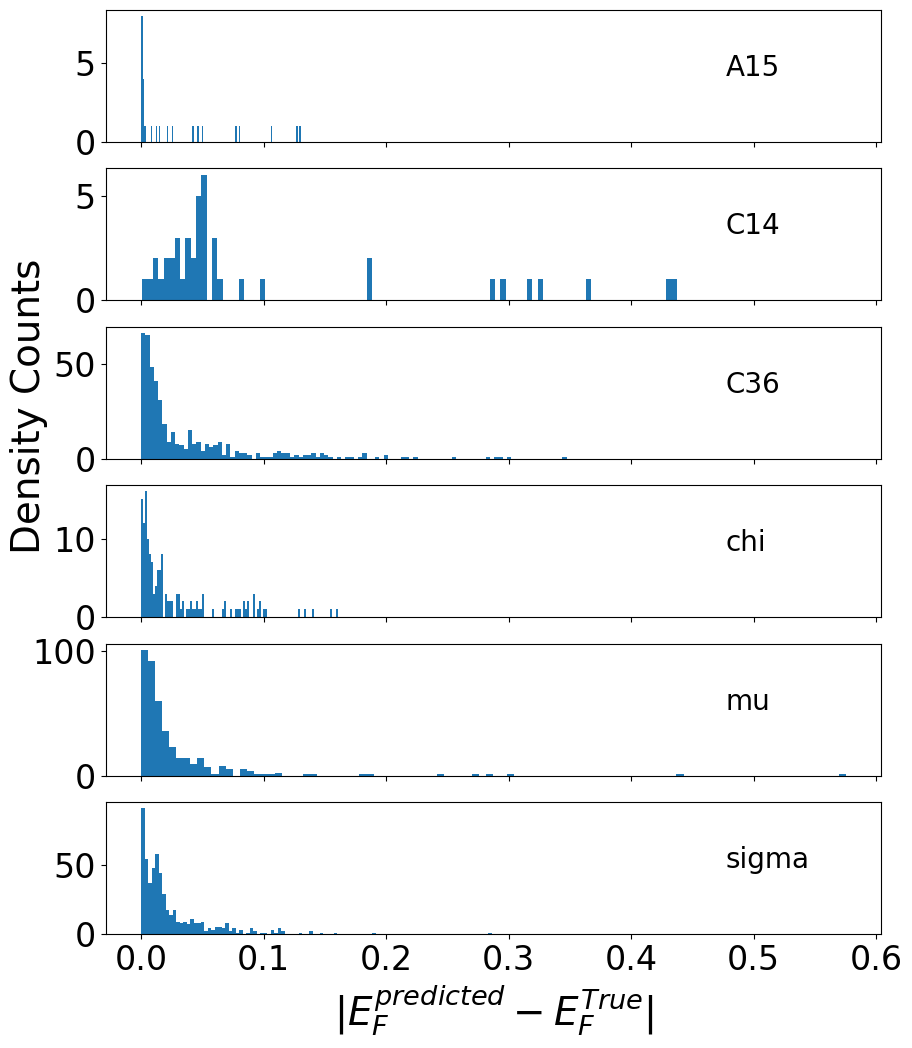

In [125]:
plot_the_errors(EPREDICT,'FeatureSelectionRandomForest')

# incremental simple model

In [126]:
def incremental_learn (columnsgroup):
    incremental_score = [] 
    progress = tqdm_notebook(range(0,len(columnsgroup)))
    for max_index in progress:
        incremental_model = RandomForestRegressor()
        all_features = np.hstack((['MagConfig_0','NSC_U_bind_0'], np.ravel(columnsgroup[:max_index])))#  + list(columns_bn[:max_index])
        feature_group = all_features
        this_feature_list = feature_group
        THHEX =DATA[feature_group].loc[X_train.index]
        incremental_model.fit(THHEX , Y_train)
        Ytrain_predict = incremental_model.predict(THHEX)
        Ytest_predict = incremental_model.predict(DATA[feature_group].loc[X_test.index])
        incremental_score.append(mean_squared_error(Y_test, Ytest_predict, squared=False))
    return incremental_score

In [127]:
cols_an_bn = [[an, bn] for an, bn in zip(columns_an, columns_bn) ]

In [128]:
incremental_score_moments = incremental_learn(columns_moments)
np.savetxt(FileNames.get_table_filename('incremental_score','moments'),incremental_score_moments)

  0%|          | 0/10 [00:00<?, ?it/s]

In [129]:
incremental_score_an = incremental_learn(cols_an_bn)
np.savetxt(FileNames.get_table_filename('incremental_score','an'),incremental_score_an)

  0%|          | 0/11 [00:00<?, ?it/s]

In [130]:
incremental_score_sigmas = incremental_learn(columns_sigma)
np.savetxt(FileNames.get_table_filename('incremental_score','sigmas'),incremental_score_sigmas)

  0%|          | 0/10 [00:00<?, ?it/s]

In [131]:
from matplotlib.ticker import FormatStrFormatter

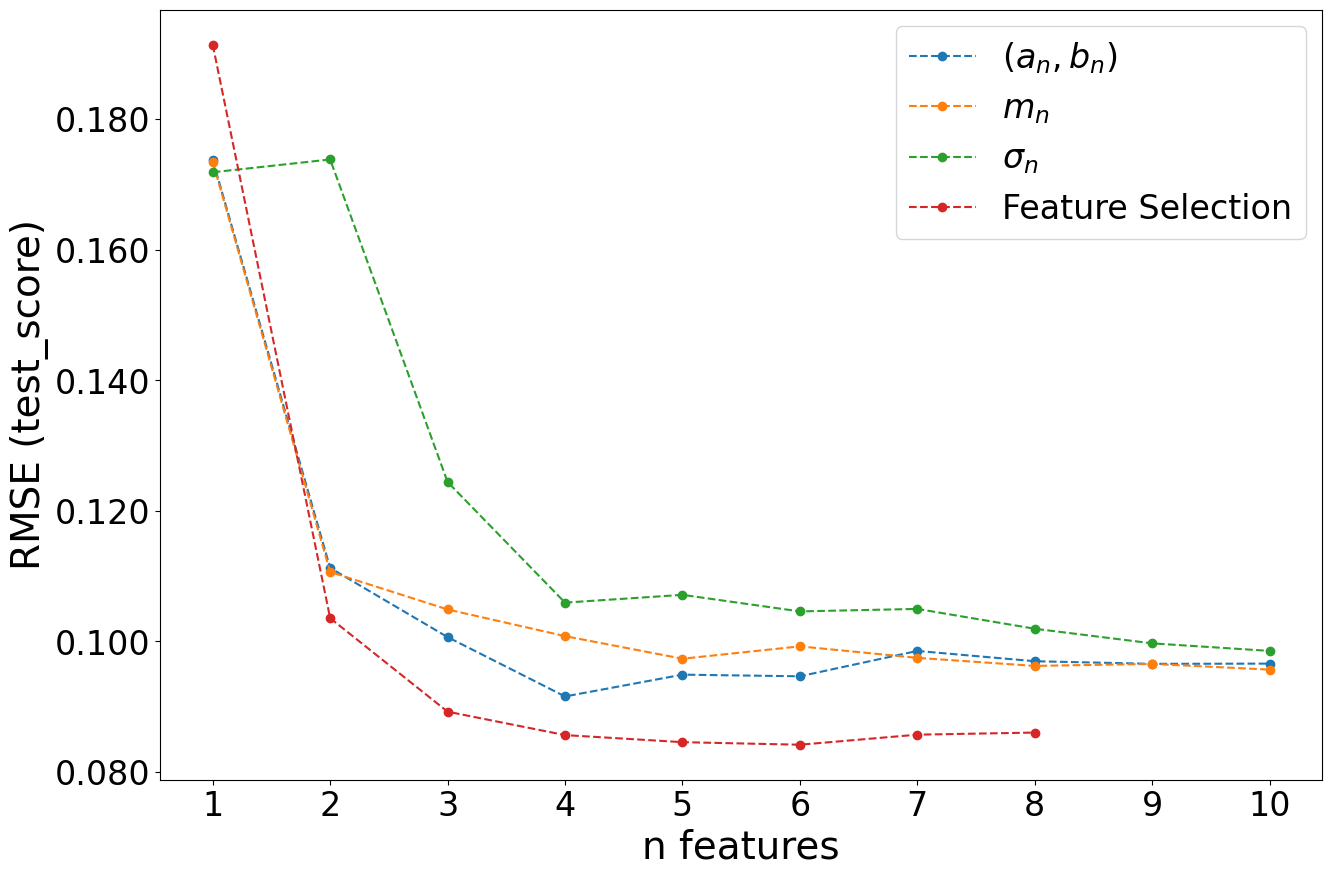

In [132]:
thex = np.linspace(1,len(incremental_score_moments), len(incremental_score_moments))
fig, ax = plt.subplots()
ax.plot(thex, incremental_score_an[:-1],'--o', label = ('$(a_n,b_n)$'))
ax.plot(thex , incremental_score_moments,'--o', label ='$m_n$')
ax.plot(thex, incremental_score_sigmas,'--o', label = '$\sigma _n$')
ax.plot(thex[:len(Bestscores['RandomForest'])], Bestscores['RandomForest'], '--o', label = 'Feature Selection')
ax.legend()
ax.set_xlabel('n features')
ax.tick_params(axis='y',)
ax.set_xticks(thex)
ax.yaxis.set_major_formatter(FormatStrFormatter('%0.3f'))
ax.set_ylabel(f'RMSE ({criterion})')
#ax.set_ylim([0.05,0.07])
fig.savefig(FileNames.get_plot_filename('OrthogonalFeatures','1stMagconfig'))

# Model Usage

In [133]:
BestDecisionTree = FC['RandomForest'].report['best_estimator'][-1]

The model was already fitted, don need to fit again, just use it to predict !

In [134]:
best_Y_train_predict = BestDecisionTree.predict(X_train[Bestfeats['RandomForest']])
best_Y_test_predict = BestDecisionTree.predict(X_test[Bestfeats['RandomForest']])

In [135]:
YPREDICT = BestDecisionTree.predict(DATA[Bestfeats['RandomForest']])

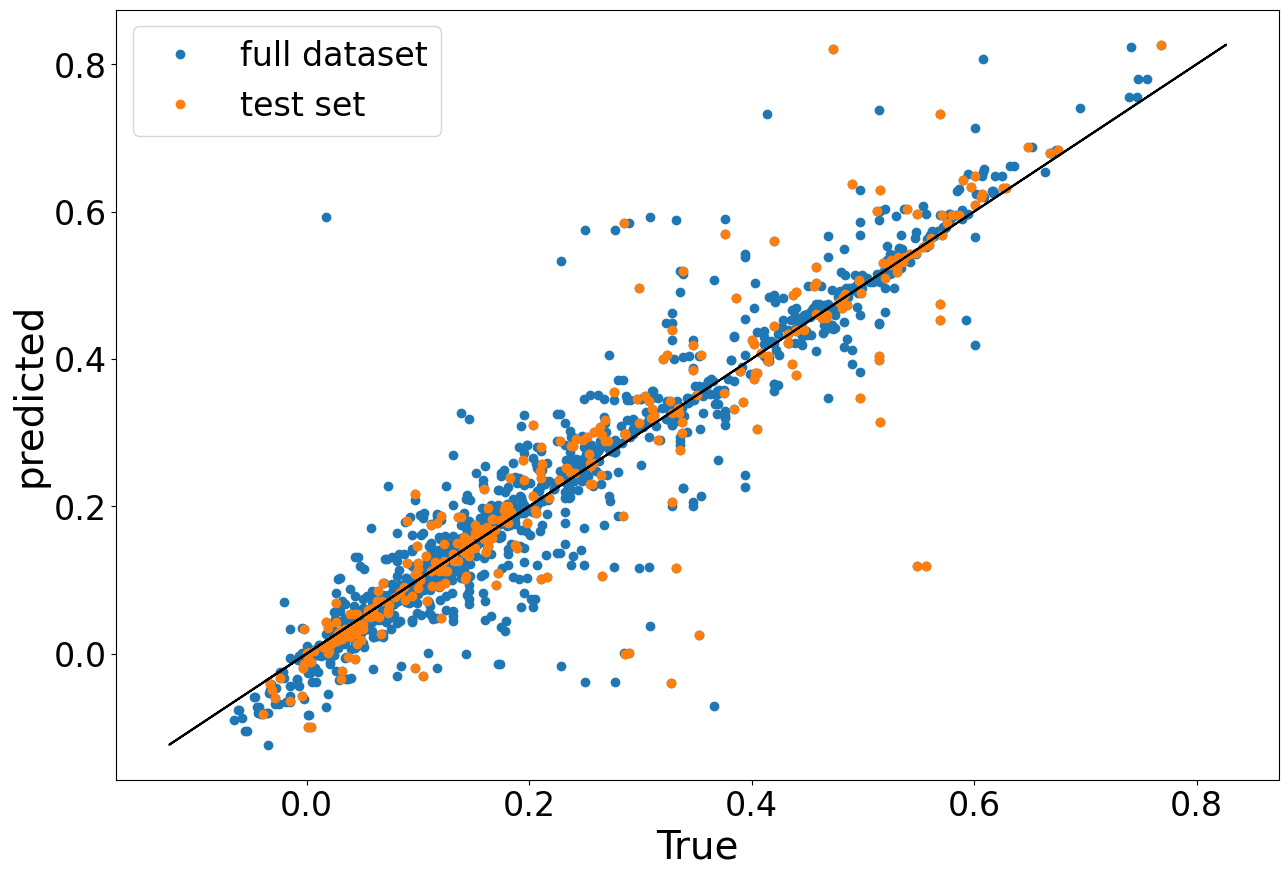

In [136]:
plot_the_prediction_line(YPREDICT,best_Y_test_predict,'BestRandomForest')